# Chunking-eval report — `study-C-aggregator`

**Branch**: `research/chunking-eval` · **Step**: 8 (eval-harness-notebook)

This notebook is the deliverable for one study of the chunking-strategy sweep.
It loads the per-scenario doc-embedding shards (from `embed_sweep`) and the
per-query embedding shard (from `query_embed`) for `study-C-aggregator`, computes
doc-level retrieval scores per `(query, scenario)`, and renders the plots and
tables that answer the headline research question:

> *Does forcing sub-context chunking + mean+L2 pool produce better doc-level
> embeddings than one-shot encoding the whole doc?*

## How to read this notebook

1. **Setup → Sanity** (sections 1–3): load inputs, verify schema/dim/lg
   alignment. Halt and fix upstream if the sanity table flags issues.
2. **Headline verdict** (section 4): one table per language showing the Δ in
   `Recall@5` vs the `S0` truncate baseline, with paired-bootstrap CIs.
3. **Plots** (sections 5–10): Recall@5 by scenario, convergence vs
   `chunk_tokens`, position-bucket robustness, MRR, query-type ablation,
   diagnostic distributions.
4. **Notes** (section 11): per-language conclusion + open follow-ups. **Edit
   this cell when re-running.**

## Scope

- **Embedding level**: `text` only (one vector per doc; mean+L2 when chunked).
  Chunk-level retrieval is out of scope on this branch.
- **Languages**: per-study (see `corpus.languages` in the YAML). Each query
  ranks against the same-language slice of the doc pool only — cross-lingual
  is the gated O4 ablation.
- **Metrics**: Recall@1/5/10, MRR; bootstrap CIs (B=1000) per metric per
  scenario; paired bootstrap for Δ vs the S0 baseline. Chunk-level IoU /
  Precision_Ω deferred (requires chunker span recovery — see notes folder).

## 1 — Setup

In [1]:
# This notebook runs end-to-end given a study YAML config. Change the
# constant below to switch studies; everything else derives from it.
import os
import sys
from pathlib import Path

# When running from the notebook (cwd = notebooks/), reach the src/ layout.
REPO_ROOT = Path(os.environ.get("IMPRESSO_REPO_ROOT", Path.cwd().resolve())).resolve()
if (REPO_ROOT / "notebooks").is_dir() is False and (REPO_ROOT.parent / "notebooks").is_dir():
    REPO_ROOT = REPO_ROOT.parent
sys.path.insert(0, str(REPO_ROOT / "src"))

STUDY_CONFIG_PATH = REPO_ROOT / "configs/research/study-C-aggregator.yaml"
assert STUDY_CONFIG_PATH.exists(), f"missing: {STUDY_CONFIG_PATH}"
print(f"study config: {STUDY_CONFIG_PATH}")

study config: /Users/adrien/Documents/nlp2/impresso-text-embedder/configs/research/study-C-aggregator.yaml


In [2]:
import logging
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from impresso_text_embedder.research import eval as ev
from impresso_text_embedder.research.scenario_builder import ScenarioRegistry
from impresso_text_embedder.research.study_config import load_study_config

# Minimal-noise log surface so notebook output stays readable.
logging.basicConfig(level=logging.INFO, format="%(asctime)s %(levelname)s %(message)s")
logging.getLogger("impresso_text_embedder").setLevel(logging.INFO)
logging.getLogger("botocore").setLevel(logging.WARNING)
logging.getLogger("s3transfer").setLevel(logging.WARNING)
warnings.filterwarnings("ignore", category=FutureWarning)

# Best-practice seaborn theme: white grid for ratio plots, colorblind palette
# (categorical axis = chunker family), tight context. dpi bumped so PNGs in
# the rendered notebook are readable at GitHub's render width without
# blowing up the file size.
sns.set_theme(
    style="whitegrid",
    context="notebook",
    palette="colorblind",
    rc={"figure.dpi": 110, "savefig.dpi": 130, "axes.titleweight": "bold"},
)

In [3]:
study_cfg = load_study_config(STUDY_CONFIG_PATH)
registry = ScenarioRegistry.from_study(study_cfg)
print(f"study={study_cfg.study.name}  config_sha={study_cfg.config_sha}")
print(f"languages={study_cfg.corpus.languages}  n_per_lg={study_cfg.corpus.n_per_lg}")
print(f"scenarios ({len(registry.all_ids())}):")
print(registry.format_table())

study=C-aggregator  config_sha=b3f66b54d63e
languages=('fr', 'de')  n_per_lg=300
scenarios (13):
id    chunker        chunk_tokens  label
----------------------------------------
S0    (none)                    -  truncate-8192
S1    token-budget           1024  token-budget-1024-first-chunk
S2    token-budget           1024  token-budget-1024-max
S3    token-budget           1024  token-budget-1024-mean
S4    token-budget           1024  token-budget-1024-length-weighted
S5    token-budget           2048  token-budget-2048-first-chunk
S6    token-budget           2048  token-budget-2048-max
S7    token-budget           2048  token-budget-2048-mean
S8    token-budget           2048  token-budget-2048-length-weighted
S9    token-budget           4096  token-budget-4096-first-chunk
S10   token-budget           4096  token-budget-4096-max
S11   token-budget           4096  token-budget-4096-mean
S12   token-budget           4096  token-budget-4096-length-weighted


## 2 — Load eval inputs

Pulls the queries-embedded shard plus every scenario shard for this study
from `s3://{study_cfg.s3.bucket}/{study_cfg.study_s3_root()}/`. Files cache
under the local mirror (`study_cfg.local_path(...)`); re-running the cell
hits the cache. Pass `force=True` to invalidate.

In [4]:
inputs = ev.load_eval_inputs(study_cfg)
print(
    f"loaded {len(inputs.queries)} queries × {len(inputs.pools)} scenarios "
    f"({sum(p.embeddings.shape[0] for p in inputs.pools.values())} doc rows total)"
)

loaded 3343 queries × 13 scenarios (7800 doc rows total)


In [5]:
inputs.study

### Study `C-aggregator` &nbsp;<sub>config_sha=`b3f66b54d63e`</sub>

**Corpus** — fr, de · 1930–1980 · ocrqa ≥ 0.84 · doc tokens 7000–8000 · 300/lg (seed 42)

- providers: **fr**: _all_, **de**: _all_
- chars/token: **fr**=3.93, **de**=4.30

**Embed** — `Alibaba-NLP/gte-multilingual-base@f7d567e` · bf16 · attn=xformers · unpad=True · min_char_length=0

**Scenarios** — 13 total · truncate_baseline=True

- chunkers: `token-budget`
- chunk_sizes: `1024`, `2048`, `4096`
- aggregators: `first-chunk`, `max`, `mean`, `length-weighted`

**Query generation** — `Qwen/Qwen3-30B-A3B-Instruct-2507` @ `https://inference.rcp.epfl.ch/v1` · T=0.7 · max_parallel=2 · 1/bucket × (head, mid, tail)

**Paths** — local: `tmp/chunking-eval/C-aggregator` · s3: `s3://140-processed-data-sandbox/chunking-eval/C-aggregator`


## 3 — Sanity checks

Every assertion here is a load-time guard against an upstream pipeline drift
that would silently invalidate the eval (mismatched embedding dim, scenarios
covering different `ci_id` sets, queries whose gold doc is absent, non-finite
or non-unit-norm embeddings). The `Issues` row is empty when everything is
green.

In [6]:
report = ev.run_sanity(inputs)

summary_rows = [
    ("queries (total)", report.n_queries),
    ("query languages", report.n_query_languages),
    ("embedding dim", report.embedding_dim),
    ("queries by lg", report.queries_lg_counts),
    ("queries by position bucket", report.queries_position_counts),
    ("queries by query_type", report.queries_type_counts),
    ("pool size per scenario", report.pool_size_per_scenario),
    ("pool lg counts (S0)", report.pool_lg_counts_per_scenario.get("S0", {})),
    ("queries with unmatched ci_id", len(report.queries_with_unmatched_ci_id)),
    ("Issues", report.issues or "(none)"),
]
sanity_df = pd.DataFrame(summary_rows, columns=["check", "value"])
sanity_df.style.set_properties(**{"text-align": "left"}).set_table_styles(
    [{"selector": "th", "props": [("text-align", "left")]}]
)

,check,value
0,queries (total),3343
1,query languages,2
2,embedding dim,768
3,queries by lg,"{'fr': 1663, 'de': 1680}"
4,queries by position bucket,"{'head': 1058, 'mid': 1134, 'tail': 1151}"
5,queries by query_type,"{'question': 1678, 'topical-phrase': 1665}"
6,pool size per scenario,"{'S0': 600, 'S1': 600, 'S2': 600, 'S3': 600, 'S4': 600, 'S5': 600, 'S6': 600, 'S7': 600, 'S8': 600, 'S9': 600, 'S10': 600, 'S11': 600, 'S12': 600}"
7,pool lg counts (S0),"{'de': 300, 'fr': 300}"
8,queries with unmatched ci_id,0
9,Issues,(none)


In [7]:
assert report.passed, f"sanity failed: {report.issues}"

## 4 — Score every (query, scenario)

`score_queries` joins each query against the same-language slice of every
scenario's doc pool, computes the cosine rank of the gold `ci_id`, and emits
a tidy DataFrame with one row per `(query_id, scenario_id)`. Persisted to
parquet so re-running the plotting cells doesn't re-score.

In [8]:
scores = ev.score_queries(inputs, k_values=(1, 5, 10))
out_dir = study_cfg.study_local_root() / "eval"
out_dir.mkdir(parents=True, exist_ok=True)
parquet_path = out_dir / "scores.parquet"
scores.to_parquet(parquet_path, index=False)
print(f"wrote {len(scores):,} score rows -> {parquet_path}")
scores.head()

wrote 43,459 score rows -> tmp/chunking-eval/C-aggregator/eval/scores.parquet


,query_id,ci_id,lg,query_type,position_bucket,scenario_id,scenario_label,chunker,chunk_tokens,aggregator,...,n_tokens,len_chars,rank,reciprocal_rank,margin,nll,recall_at_1,recall_at_5,recall_at_10,token_bucket
0,FedGazFr-1930-03-26-a-i0002__head__question__00,FedGazFr-1930-03-26-a-i0002,fr,question,head,S0,truncate-8192,truncate,<NA>,(none),...,6378,27134,1.0,1.0,0.037988,2.606313,True,True,True,6k-8k
1,FedGazFr-1930-03-26-a-i0002__mid__question__00,FedGazFr-1930-03-26-a-i0002,fr,question,mid,S0,truncate-8192,truncate,<NA>,(none),...,6378,27134,1.0,1.0,0.080609,1.88644,True,True,True,6k-8k
2,FedGazFr-1930-03-26-a-i0002__mid__topical-phra...,FedGazFr-1930-03-26-a-i0002,fr,topical-phrase,mid,S0,truncate-8192,truncate,<NA>,(none),...,6378,27134,1.0,1.0,0.077161,2.057157,True,True,True,6k-8k
3,FedGazFr-1930-03-26-a-i0002__tail__question__00,FedGazFr-1930-03-26-a-i0002,fr,question,tail,S0,truncate-8192,truncate,<NA>,(none),...,6378,27134,1.0,1.0,0.084081,1.780009,True,True,True,6k-8k
4,FedGazFr-1930-03-26-a-i0002__tail__topical-phr...,FedGazFr-1930-03-26-a-i0002,fr,topical-phrase,tail,S0,truncate-8192,truncate,<NA>,(none),...,6378,27134,1.0,1.0,0.042023,2.532672,True,True,True,6k-8k


In [27]:
type(scores['chunk_tokens'][0])

pandas._libs.missing.NAType

0        True
1        True
2        True
3        True
4        True
         ... 
43454    True
43455    True
43456    True
43457    True
43458    True
Name: chunk_tokens, Length: 43459, dtype: boolean

In [9]:
# Order scenarios by registry position so every plot keeps the same x-axis.
SCENARIO_ORDER = registry.all_ids()
SCENARIO_LABELS = {s.id: f"{s.id} · {s.label}" for s in registry.all_scenarios()}
AGG_ORDER = [ "(none)", "first-chunk", "max", "mean", "length-weighted"]
LG_ORDER = list(study_cfg.corpus.languages)

# Long display labels render better on rotated x-axes than ids alone.
scores["scenario_display"] = scores["scenario_id"].map(SCENARIO_LABELS)
scenario_display_order = [SCENARIO_LABELS[s] for s in SCENARIO_ORDER]

## 2 — Margin to Goal

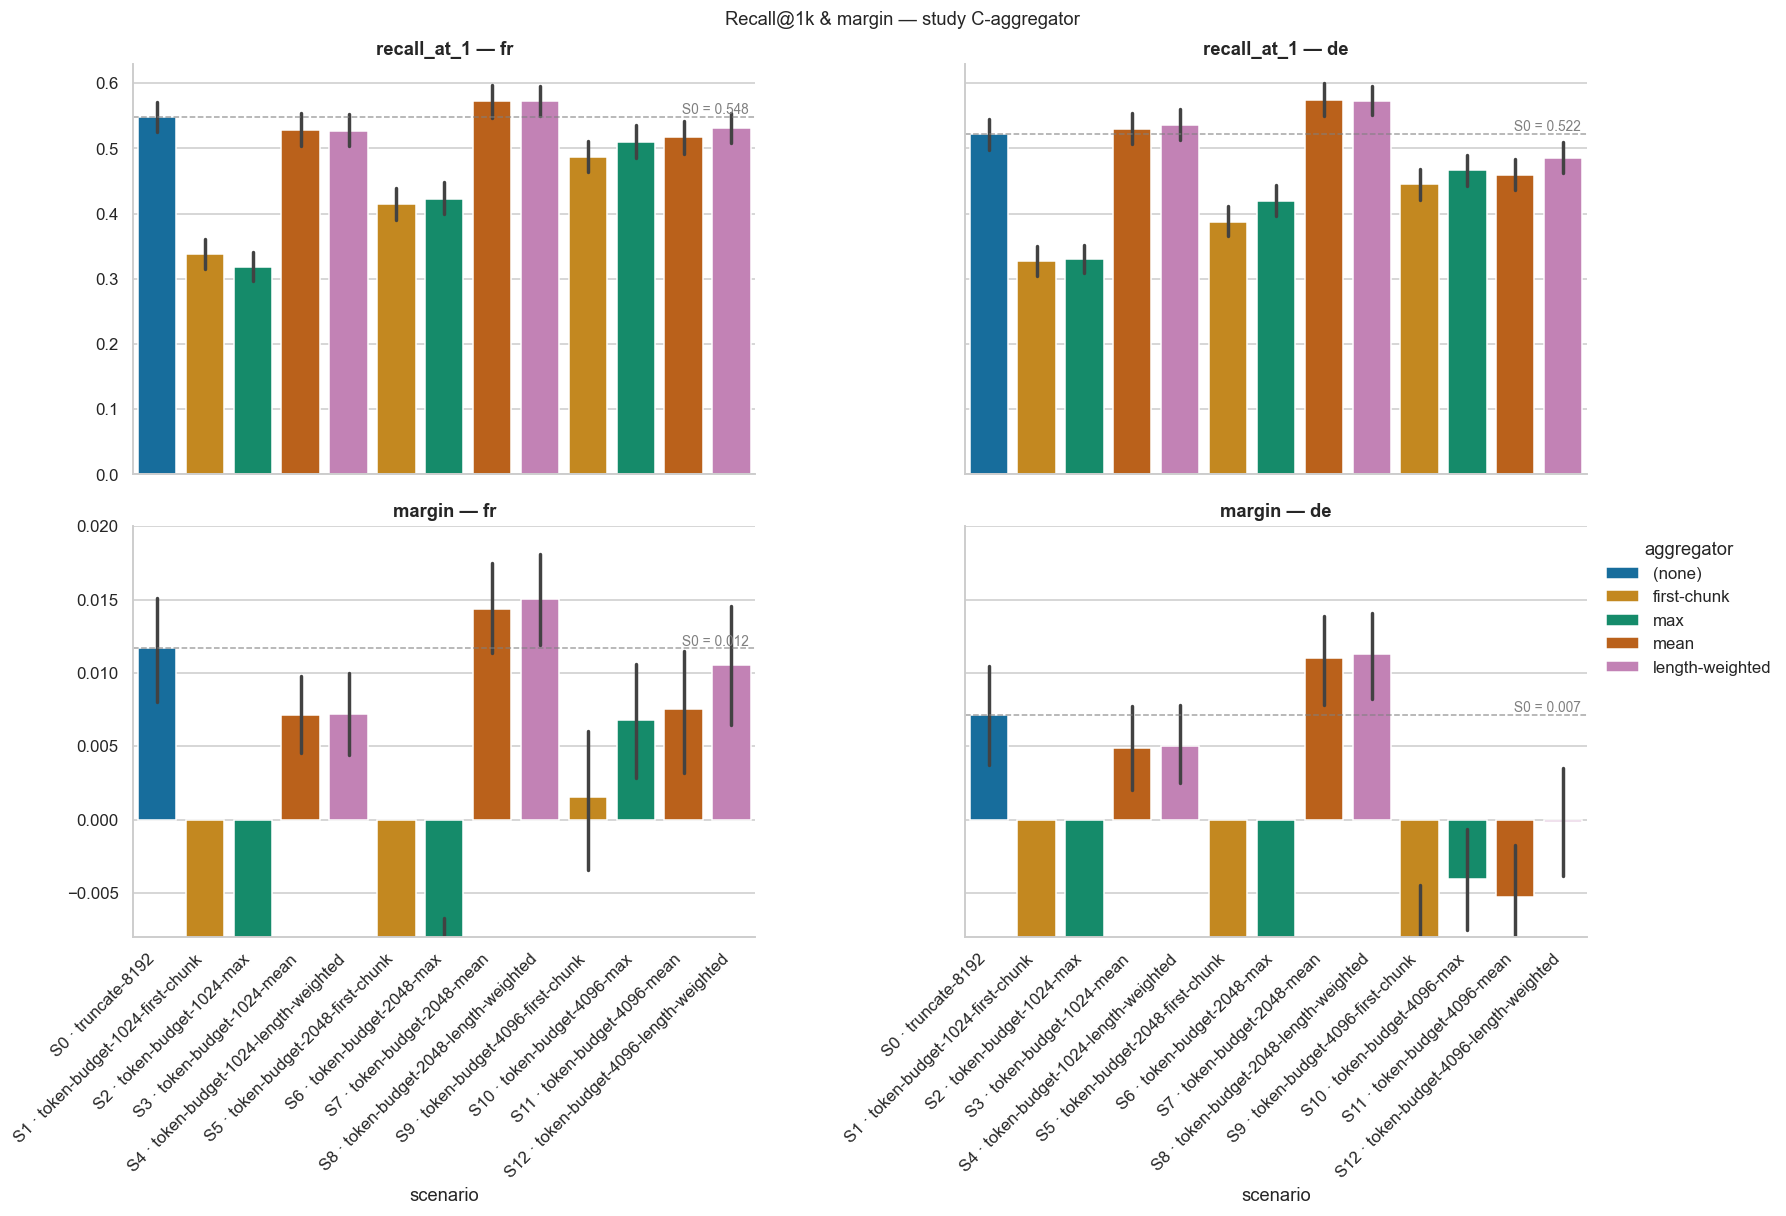

In [10]:
def _palette_for_aggregators():
    base = sns.color_palette("colorblind", n_colors=len(AGG_ORDER))
    return dict(zip(AGG_ORDER, base, strict=True))

agg_palette = _palette_for_aggregators()

long = scores.melt(
    id_vars=["scenario_display", "scenario_id", "aggregator", "lg"],                                                                                                                                                                                                                                                 
    value_vars=["recall_at_1", "margin"],                                                                                                                                                                                                                                                                            
    var_name="metric", value_name="value",                                                                                                                                                                                                                                                                        
)                                                                                                                                                                                                                                                                                                                 
                                        
g = sns.catplot(                                                                                                                                                                                                                                                                                                  
    data=long,                         
    x="scenario_display", y="value",    
    hue="aggregator", hue_order=AGG_ORDER, palette=agg_palette,
    row="metric", row_order=["recall_at_1", "margin"],                                                                                                                                                                                                                                                               
    col="lg", col_order=LG_ORDER,                                                                                                                                                                                                                                                                                 
    kind="bar", order=scenario_display_order,                                                                                                                                                                                                                                                                     
    errorbar=("ci", 95),                                                                                                                                                                                                                                                                                          
    height=4.5, aspect=1.6, dodge=False,
    sharey="row",  # each metric keeps its own y-scale                                                                                                                                                                                                                                                            
    legend_out=True,                                                                                                                                                                                                                                                                                              
)                                                                                                                                                                                                                                                                                                                 
g.set_titles("{row_name} — {col_name}")       
g.set_axis_labels("scenario", "")     

                                    
for (metric, lg), ax in g.axes_dict.items():                                                                                                                                                                                                                                                                      
    s0 = float(scores[(scores.lg == lg) & (scores.scenario_id == "S0")][metric].mean())
    ax.axhline(s0, ls="--", color="gray", lw=1, alpha=0.7)                                                                                                                                                                                                                                                        
    ax.text(0.99, s0, f" S0 = {s0:.3f}",
            transform=ax.get_yaxis_transform(),                                                                                                                                                                                                                                                                   
            ha="right", va="bottom", color="gray", fontsize=9)
    if metric == "margin":                                                                                                                                                                                                                                                                                        
        ax.set_ylim(-0.008, 0.02)

g.set_axis_labels("scenario", "") 
for ax in g.axes[-1]: 
    ax.tick_params(axis="x", labelbottom=True)
    plt.setp(ax.get_xticklabels(), rotation=45, ha="right")    
                                                                                                                                                                                                                                                                                                                
g.figure.suptitle(f"Recall@1k & margin — study {study_cfg.study.name}",                                                                                                                                                                                                                                           
                y=1.01, fontsize=12)  
plt.show()    


## 8 — Position-bucket robustness

The whole point of step 4's head/mid/tail bucketing: a chunker that always
keeps the head but loses the tail should show a tail-bucket cliff here. For
study-A-fit (docs ≤ context) we expect S0 to be roughly position-flat;
chunkers may differ.

In [11]:
long

,scenario_display,scenario_id,aggregator,lg,metric,value
0,S0 · truncate-8192,S0,(none),fr,recall_at_1,True
1,S0 · truncate-8192,S0,(none),fr,recall_at_1,True
2,S0 · truncate-8192,S0,(none),fr,recall_at_1,True
3,S0 · truncate-8192,S0,(none),fr,recall_at_1,True
4,S0 · truncate-8192,S0,(none),fr,recall_at_1,True
...,...,...,...,...,...,...
86913,S12 · token-budget-4096-length-weighted,S12,length-weighted,de,margin,0.163254
86914,S12 · token-budget-4096-length-weighted,S12,length-weighted,de,margin,0.139966
86915,S12 · token-budget-4096-length-weighted,S12,length-weighted,de,margin,0.10875
86916,S12 · token-budget-4096-length-weighted,S12,length-weighted,de,margin,-0.056773


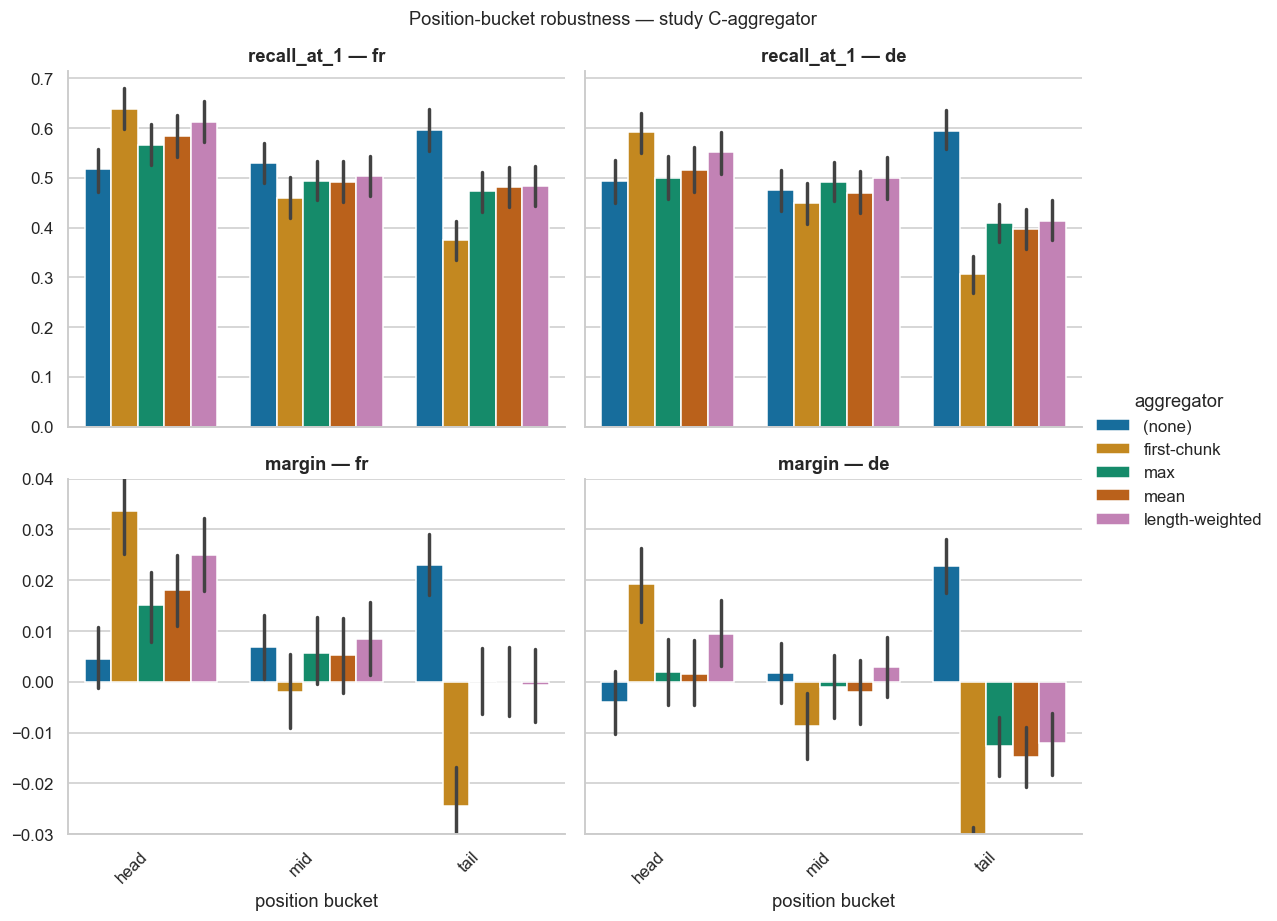

In [31]:
position_order = list(study_cfg.query_generation.position_buckets)

scores["chunker"]

long = scores[scores['chunk_tokens'].isin([pd.NA, 4096])].melt(
    id_vars=["position_bucket", "aggregator", "lg"],                                                                                                                                                                                                                                                                 
    value_vars=["recall_at_1", "margin"],                                                                                                                                                                                                                                                                            
    var_name="metric", value_name="value",
)                                                                                                                                                                                                                                                                                                                 
                                        
g = sns.catplot(                        
    data=long,                    
    x="position_bucket", y="value",                                                                                                                                                                                                                                                                               
    hue="aggregator", hue_order=AGG_ORDER, palette=agg_palette,
    row="metric", row_order=["recall_at_1", "margin"],                                                                                                                                                                                                                                                            
    col="lg", col_order=LG_ORDER,                                                                                                                                                                                                                                                                                 
    order=position_order,               
    kind="bar",                                                                                                                                                                                                                                                                                                   
    height=4, aspect=1.3,              
    errorbar=("ci", 95),                                                                                                                                                                                                                                                                                          
    sharey="row",                 
)                                                                                                                                                                                                                                                                                                                 
g.set_titles("{row_name} — {col_name}")
g.set_axis_labels("position bucket", "")                                                                                                                                                                                                                                                                          
                                
for (metric, _lg), ax in g.axes_dict.items():                                                                                                                                                                                                                                                                     
    if metric == "margin":           
        ax.set_ylim(-0.04, 0.04)                                                                                                                                                                                                                                                                                 
                                                                                                                                                                                                                                                                                                                
for ax in g.axes[-1]:  # bottom row only
    ax.tick_params(axis="x", labelbottom=True)                                                                                                                                                                                                                                                                    
    plt.setp(ax.get_xticklabels(), rotation=45, ha="right")
                                                                                                                                                                                                                                                                                                                
g.figure.suptitle(                
    f"Position-bucket robustness — study {study_cfg.study.name}",                                                                                                                                                                                                                                                 
    y=1.02, fontsize=12,                                                                                                                                                                                                                                                                                          
)                                       
plt.show()     

## 10 — Query-type ablation

Closes O9 — does `question` retrieve differently than `topical-phrase`? If
one type dominates the signal (e.g. `topical-phrase` is the only metric the
chunker affects), the eval can stratify on it for the verdict.

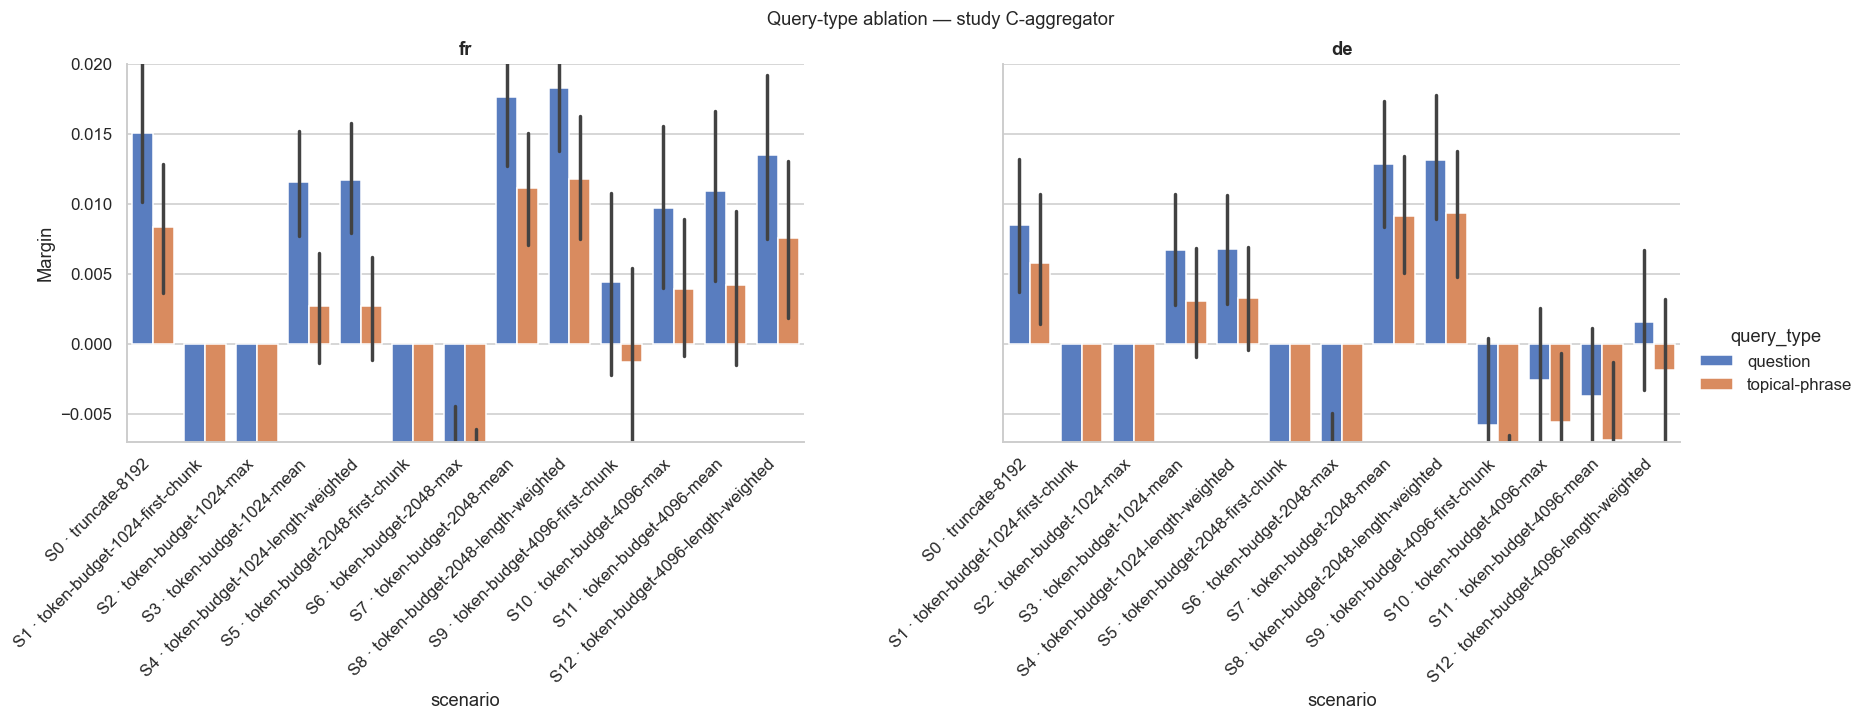

In [13]:
g = sns.catplot(
    data=scores,
    x="scenario_display",
    y="margin",
    hue="query_type",
    palette="muted",
    col="lg",
    col_order=LG_ORDER,
    order=scenario_display_order,
    kind="bar",
    height=4.5,
    aspect=1.7,
    errorbar=("ci", 95),
)
g.set_titles("{col_name}")
g.set_xticklabels(rotation=45, ha="right")
g.set_axis_labels("scenario", "Margin")
for ax in g.axes.flat:
    ax.set_ylim(-0.007, 0.02)
g.figure.suptitle(
    f"Query-type ablation — study {study_cfg.study.name}",
    y=1.02, fontsize=12,
)
plt.show()

#### 11c-ii — Truncation loss on the S0 baseline

`S0` truncates at `model.max_seq_length` (8190 for `gte-multilingual-base`).
For every gold doc with `n_tokens > 8190`, S0 silently drops the tail. This
table reports per-language, per-token-bucket: how often it happened, mean
tokens dropped, and Recall@5 within the bucket so we can see whether the
truncated docs are also the docs S0 fails on.

In [14]:
df = pd.DataFrame(np.array([inputs.pools["S2"].langs, inputs.pools["S2"].n_tokens, inputs.pools["S2"].len_chars]).T, columns=["lg", "n_tokens", "len_chars"])
df["ratio"] = df["len_chars"] / df["n_tokens"]
df[["ratio", "lg"]].groupby("lg").agg(["count", "mean", "std", "min", ("p10", lambda s: float(s.quantile(0.10))), ("p50", lambda s: float(s.median())), ("p90", lambda s: float(s.quantile(0.90))), "max"])    

ratio                                                                      
   count      mean       std       min       p10       p50       p90       max
lg                                                                            
de   300  4.301297  0.239473  3.607833  3.965438  4.314165  4.596857  4.864672
fr   300  3.933344  0.253148  3.282444  3.587903  3.957991  4.244378  4.576544